<a href="https://colab.research.google.com/github/yasuuonx/pattern-recognition-practice/blob/main/notebooks/PR02_Demchenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 2
## Дослідницький аналіз і підготовка даних
**Дисципліна:** Розпізнавання образів і машинне навчання
**Студент:** Демченко Станіслав
**Група:** 42/1
**Дата виконання:** 08.10.2026

### Мета роботи
Навчитися аналізувати якість табличних даних, виявляти та виправляти пропуски, дублікати, неправильні типи й аномальні значення, кодувати категоріальні ознаки та формувати навчальну і тестову вибірки.

## 1. Підключення бібліотек
Підключаються бібліотеки для роботи з таблицями, числовими даними, візуалізацією, збереженням метаданих і формуванням train/test-вибірок.

In [29]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from IPython.display import display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.16
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1


## 2. Підключення Google Drive та створення робочих папок
Google Drive використовується для читання початкових даних і збереження результатів очищення.

In [30]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

SOURCE_PATH = DATA_DIR / "iris.csv"
DIRTY_PATH = DATA_DIR / "iris_dirty.csv"
CLEANED_PATH = PROCESSED_DIR / "iris_cleaned.csv"
X_TRAIN_PATH = PROCESSED_DIR / "X_train.csv"
X_TEST_PATH = PROCESSED_DIR / "X_test.csv"
Y_TRAIN_PATH = PROCESSED_DIR / "y_train.csv"
Y_TEST_PATH = PROCESSED_DIR / "y_test.csv"
SUMMARY_PATH = REPORTS_DIR / "preprocessing_summary.csv"
CLASS_MAPPING_PATH = REPORTS_DIR / "class_mapping.json"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Папка проєкту:", PROJECT_DIR)
print("Папка початкових даних:", DATA_DIR)
print("Папка підготовлених даних:", PROCESSED_DIR)
print("Папка звітів:", REPORTS_DIR)

Папка проєкту: /content/drive/MyDrive/pattern-recognition-practice
Папка початкових даних: /content/drive/MyDrive/pattern-recognition-practice/data
Папка підготовлених даних: /content/drive/MyDrive/pattern-recognition-practice/data/processed
Папка звітів: /content/drive/MyDrive/pattern-recognition-practice/reports


## 3. Завантаження початкового набору Iris
Перевіряється наявність файла iris.csv. Якщо файл відсутній, він створюється автоматично.

In [32]:
if SOURCE_PATH.exists():
    source_df = pd.read_csv(SOURCE_PATH)
    print("Початковий файл завантажено з Google Drive.")
else:
    print("Файл iris.csv не знайдено. Створюємо його повторно.")
    iris = load_iris(as_frame=True)
    source_df = iris.frame.copy()
    source_df["species"] = source_df["target"].map({
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    })
    source_df = source_df.drop(columns=["target"])
    source_df = source_df.rename(
        columns={
            "sepal length (cm)": "sepal_length_cm",
            "sepal width (cm)": "sepal_width_cm",
            "petal length (cm)": "petal_length_cm",
            "petal width (cm)": "petal_width_cm"
        }
    )
    source_df.to_csv(SOURCE_PATH, index=False)
    print("Файл iris.csv створено:", SOURCE_PATH)

display(source_df.head())
print("Розмір початкової таблиці:", source_df.shape)

Початковий файл завантажено з Google Drive.


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Розмір початкової таблиці: (150, 5)


## 4. Створення набору з контрольованими проблемами
До початкового набору додаються категоріальна ознака з різним регістром, текстові артефакти, пропуски, аномалії та дублікати.

In [33]:
rng = np.random.default_rng(42)
dirty_df = source_df.copy()

# Додаємо категоріальну ознаку пристрою
dirty_df["measurement_device"] = rng.choice(
    ["device_a", "device_b", "device_c"],
    size=len(dirty_df),
    p=[0.40, 0.35, 0.25]
)

# Додаємо пропуски за планом
missing_plan = {
    "sepal_length_cm": 4,
    "sepal_width_cm": 5,
    "petal_length_cm": 4,
    "petal_width_cm": 5,
    "measurement_device": 4,
    "species": 2
}

for column, amount in missing_plan.items():
    selected_indices = rng.choice(dirty_df.index, size=amount, replace=False)
    dirty_df.loc[selected_indices, column] = np.nan

# Створюємо стовпець object з некоректним текстом
dirty_df["sepal_length_cm"] = dirty_df["sepal_length_cm"].astype("object")
dirty_df.loc[3, "sepal_length_cm"] = "5,1"
dirty_df.loc[25, "sepal_length_cm"] = "unknown"
dirty_df.loc[47, "sepal_length_cm"] = "  6.3"

# Додаємо неузгоджені назви пристроїв
dirty_df.loc[7, "measurement_device"] = "Device A"
dirty_df.loc[19, "measurement_device"] = "DEVICE_B"
dirty_df.loc[33, "measurement_device"] = "device c"

# Некоректні та екстремальні значення
dirty_df.loc[10, "petal_length_cm"] = -1.0
dirty_df.loc[55, "sepal_width_cm"] = 18.0
dirty_df.loc[120, "petal_width_cm"] = 9.5

# Повні дублікати
duplicate_rows = dirty_df.iloc[[6, 27, 50, 88]].copy()
dirty_df = pd.concat([dirty_df, duplicate_rows], ignore_index=True)

dirty_df.to_csv(DIRTY_PATH, index=False)
print("Пошкоджений набір створено:", DIRTY_PATH)
print("Розмір:", dirty_df.shape)

Пошкоджений набір створено: /content/drive/MyDrive/pattern-recognition-practice/data/iris_dirty.csv
Розмір: (154, 6)


In [34]:
raw_df = pd.read_csv(DIRTY_PATH)
display(raw_df.head())
print("Розмір завантаженої пошкодженої таблиці:", raw_df.shape)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,NaN,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,"5,1",3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a


Розмір завантаженої пошкодженої таблиці: (154, 6)


## 5. Початковий аудит якості даних
Збираємо інформацію про типи, пропуски, аномалії та дублікати без внесення змін.

In [35]:
display(raw_df.head(10))
display(raw_df.tail(10))
raw_df.info()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,NaN,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,"5,1",3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a
5,5.4,3.9,1.7,NaN,setosa,device_c
6,4.6,3.4,1.4,0.3,setosa,device_c
7,5.0,3.4,1.5,0.2,setosa,Device A
8,4.4,2.9,1.4,0.2,setosa,device_a
9,4.9,3.1,1.5,0.1,setosa,device_b


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
144,6.7,3.3,5.7,2.5,virginica,device_b
145,6.7,3.0,5.2,2.3,virginica,device_a
146,6.3,2.5,5.0,1.9,virginica,device_a
147,6.5,3.0,NaN,2.0,virginica,device_b
148,6.2,3.4,5.4,2.3,virginica,device_b
149,5.9,3.0,5.1,1.8,virginica,device_a
150,4.6,3.4,1.4,0.3,setosa,device_c
151,5.2,3.5,1.5,0.2,setosa,device_a
152,7.0,3.2,4.7,1.4,versicolor,device_a
153,5.6,3.0,4.1,1.3,versicolor,device_a


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal_length_cm     150 non-null    object 
 1   sepal_width_cm      149 non-null    float64
 2   petal_length_cm     150 non-null    float64
 3   petal_width_cm      149 non-null    float64
 4   species             152 non-null    object 
 5   measurement_device  150 non-null    object 
dtypes: float64(3), object(3)
memory usage: 7.3+ KB


In [36]:
quality_report = pd.DataFrame({
    "data_type": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": raw_df.isna().mean().mul(100).round(2),
    "unique_count": raw_df.nunique(dropna=True)
})
display(quality_report)

,data_type,missing_count,missing_percent,unique_count
sepal_length_cm,object,4,2.60,38
sepal_width_cm,float64,5,3.25,24
petal_length_cm,float64,4,2.60,43
petal_width_cm,float64,5,3.25,23
species,object,2,1.30,3
measurement_device,object,4,2.60,6


### Відповіді на запитання аудиту якості:
1. **Стовпці з пропусками:** Усі стовпці (`sepal_length_cm`, `sepal_width_cm`, `petal_length_cm`, `petal_width_cm`, `measurement_device`, `species`) містять пропущені значення.
2. **Неправильний тип:** Стовпець `sepal_length_cm` має тип `object`, хоча має бути числовим (`float64`).
3. **Кількість унікальних значень цільової змінної:** 3 унікальних значення (`setosa`, `versicolor`, `virginica`).
4. **Кількість унікальних значень категоріальної ознаки:** 6 варіантів запису.
5. **Чому варіантів пристроїв більше 3:** Через різний регістр символів (`Device A`, `DEVICE_B`) та зайві пробіли або дефіси, які pandas розпізнає як окремі категорії.

,missing_count,missing_percent
sepal_width_cm,5,3.25
petal_width_cm,5,3.25
sepal_length_cm,4,2.60
petal_length_cm,4,2.60
measurement_device,4,2.60
species,2,1.30


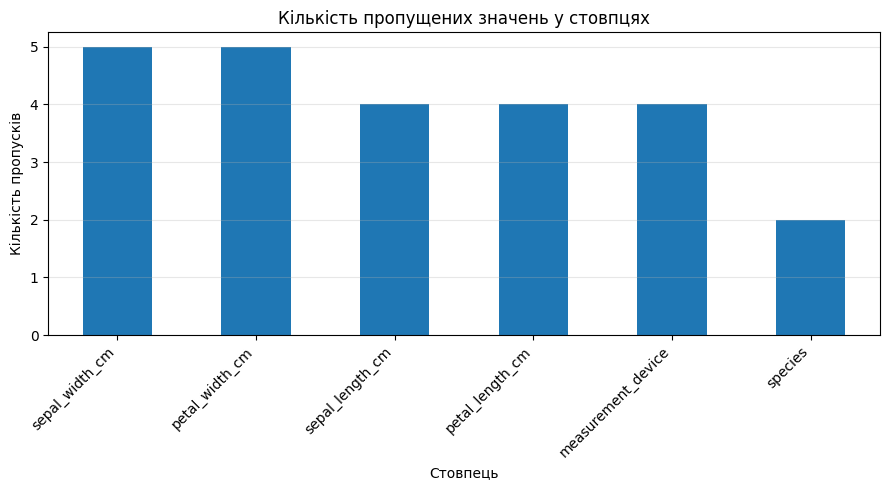

In [37]:
missing_report = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percent": raw_df.isna().mean().mul(100).round(2)
}).sort_values(by="missing_count", ascending=False)

display(missing_report)

missing_report["missing_count"].plot(kind="bar", figsize=(9, 5))
plt.title("Кількість пропущених значень у стовпцях")
plt.xlabel("Стовпець")
plt.ylabel("Кількість пропусків")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Відповіді на запитання щодо пропусків:
1. **Стовпці з найбільшою кількістю пропусків:** Числові ознаки ширини (`sepal_width_cm` та `petal_width_cm`).
2. **Критичність:** Частка пропусків складає близько 2-4%, що не є критичним і дозволяє зберегти більшість спостережень через заповнення.
3. **Спосіб заповнення для числових ознак:** Медіана (вона стійка до аномальних викидів).
4. **Спосіб заповнення для категоріальних ознак:** Мода (найбільш часте значення категорії).
5. **Чому пропуски цільової змінної не заповнюють модою:** У навчанні з учителем це створило б штучно неправдиву розмітку даних і погіршило б об'єктивність моделі. Рядки без мітки класу видаляють.

In [38]:
duplicate_mask = raw_df.duplicated(keep=False)
duplicate_count = raw_df.duplicated().sum()
print("Кількість додаткових дублікатів:", duplicate_count)
print("Кількість рядків у групах дублікатів:", duplicate_mask.sum())

duplicates_table = raw_df.loc[duplicate_mask].sort_values(by=list(raw_df.columns))
display(duplicates_table)

Кількість додаткових дублікатів: 4
Кількість рядків у групах дублікатів: 8


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
6,4.6,3.4,1.4,0.3,setosa,device_c
150,4.6,3.4,1.4,0.3,setosa,device_c
27,5.2,3.5,1.5,0.2,setosa,device_a
151,5.2,3.5,1.5,0.2,setosa,device_a
88,5.6,3.0,4.1,1.3,versicolor,device_a
153,5.6,3.0,4.1,1.3,versicolor,device_a
50,7.0,3.2,4.7,1.4,versicolor,device_a
152,7.0,3.2,4.7,1.4,versicolor,device_a


In [39]:
numeric_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]
print("Типи числових стовпців:")
print(raw_df[numeric_columns].dtypes)

invalid_numeric_summary = []
for column in numeric_columns:
    prepared_text = (
        raw_df[column]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    converted_values = pd.to_numeric(prepared_text, errors="coerce")
    invalid_mask = prepared_text.notna() & converted_values.isna()
    invalid_numeric_summary.append({
        "column": column,
        "invalid_count": int(invalid_mask.sum()),
        "invalid_values": raw_df.loc[invalid_mask, column].astype(str).tolist()
    })

invalid_numeric_summary_df = pd.DataFrame(invalid_numeric_summary)
display(invalid_numeric_summary_df)

Типи числових стовпців:
sepal_length_cm     object
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
dtype: object


,column,invalid_count,invalid_values
0,sepal_length_cm,1,[unknown]
1,sepal_width_cm,0,[]
2,petal_length_cm,0,[]
3,petal_width_cm,0,[]


In [40]:
print("Початкові варіанти measurement_device:")
for value in raw_df["measurement_device"].dropna().unique():
    print(repr(value))

device_counts_raw = raw_df["measurement_device"].value_counts(dropna=False)
display(device_counts_raw.rename("count").to_frame())

Початкові варіанти measurement_device:
'device_c'
'device_b'
'device_a'
'Device A'
'DEVICE_B'
'device c'


,count
measurement_device,
device_b,58
device_a,57
device_c,32
NaN,4
Device A,1
DEVICE_B,1
device c,1


## 6. Очищення та попередня обробка даних
Виконуємо створення робочої копії, видалення дублікатів, приведення типів, уніфікацію категорій, видалення рядків без мітки класу та заповнення пропусків.

In [41]:
clean_df = raw_df.copy()

rows_before_duplicates = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
rows_after_duplicates = len(clean_df)
removed_duplicates = rows_before_duplicates - rows_after_duplicates

print("Рядків до видалення:", rows_before_duplicates)
print("Рядків після видалення:", rows_after_duplicates)
print("Видалено дублікатів:", removed_duplicates)

clean_df = clean_df.reset_index(drop=True)

Рядків до видалення: 154
Рядків після видалення: 150
Видалено дублікатів: 4


In [42]:
for column in numeric_columns:
    prepared_text = (
        clean_df[column]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    clean_df[column] = pd.to_numeric(prepared_text, errors="coerce")

print("Типи після виправлення:")
print(clean_df[numeric_columns].dtypes)

Типи після виправлення:
sepal_length_cm    Float64
sepal_width_cm     Float64
petal_length_cm    Float64
petal_width_cm     Float64
dtype: object


In [43]:
# Стандартизація пристроїв
clean_df["measurement_device"] = (
    clean_df["measurement_device"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)
print("Категорії пристроїв після стандартизації:")
print(clean_df["measurement_device"].dropna().value_counts())

# Стандартизація та фільтрація species
clean_df["species"] = (
    clean_df["species"]
    .astype("string")
    .str.strip()
    .str.lower()
)
valid_species = {"setosa", "versicolor", "virginica"}
invalid_species_mask = clean_df["species"].notna() & ~clean_df["species"].isin(valid_species)
clean_df.loc[invalid_species_mask, "species"] = pd.NA

missing_target_count = clean_df["species"].isna().sum()
print("Кількість об'єктів без цільової змінної:", missing_target_count)

clean_df = clean_df.dropna(subset=["species"]).copy()
clean_df = clean_df.reset_index(drop=True)
print("Рядків після видалення пропусків species:", len(clean_df))

Категорії пристроїв після стандартизації:
measurement_device
device_b    59
device_a    55
device_c    32
Name: count, dtype: Int64
Кількість об'єктів без цільової змінної: 2
Рядків після видалення пропусків species: 148


In [44]:
def extreme_outlier_mask(series, factor=3.0):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    mask = (series < lower_bound) | (series > upper_bound)
    return mask, lower_bound, upper_bound

anomaly_report_rows = []
anomaly_masks = {}

for column in numeric_columns:
    statistical_mask, lower_bound, upper_bound = extreme_outlier_mask(clean_df[column], factor=3.0)
    impossible_mask = clean_df[column] <= 0
    combined_mask = statistical_mask | impossible_mask
    anomaly_masks[column] = combined_mask
    anomaly_report_rows.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "impossible_count": int(impossible_mask.sum()),
        "extreme_count": int(statistical_mask.sum()),
        "total_flagged": int(combined_mask.sum())
    })

anomaly_report = pd.DataFrame(anomaly_report_rows)
display(anomaly_report)

for column, mask in anomaly_masks.items():
    if mask.any():
        print(f"\nАномальні значення у {column}:")
        display(clean_df.loc[mask, [column, "species"]])

,column,lower_bound,upper_bound,impossible_count,extreme_count,total_flagged
0,sepal_length_cm,1.20,10.3,0,0,0
1,sepal_width_cm,1.15,5.0,0,1,1
2,petal_length_cm,-9.30,15.9,1,0,1
3,petal_width_cm,-4.20,6.3,0,1,1



Аномальні значення у sepal_width_cm:


,sepal_width_cm,species
55,18.0,versicolor



Аномальні значення у petal_length_cm:


,petal_length_cm,species
10,-1.0,setosa



Аномальні значення у petal_width_cm:


,petal_width_cm,species
119,9.5,virginica


### Відповіді на аналіз аномалій:
1. **Чому значення -1.0 фізично неможливе:** Лінійні розміри квітки не можуть бути від'ємними або дорівнювати нулю.
2. **Чому 18.0 і 9.5 малоймовірні:** Вони в рази перевищують природні розміри частин рослин Iris (більшість пелюсток мають розміри 0.1–7 см).
3. **Чи обов'язково видаляти всі значення за межами 1.5 IQR:** Ні, діапазон 1.5 IQR часто містить природні особливості рідкісних зразків, які не є помилками вимірювання.
4. **Чому коефіцієнт k = 3.0:** Такий множник відсікає лише екстремальні викиди та грубі помилки збору інформації, зберігаючи природну дисперсію ознак.

In [45]:
# Заміна аномалій на NaN
for column, mask in anomaly_masks.items():
    clean_df.loc[mask, column] = np.nan

# Заповнення пропусків числових ознак медіанами
numeric_medians = clean_df[numeric_columns].median()
display(numeric_medians.rename("median").to_frame())
clean_df[numeric_columns] = clean_df[numeric_columns].fillna(numeric_medians)

# Заповнення пропусків категорій модою
device_mode = clean_df["measurement_device"].mode().iloc[0]
print("Мода measurement_device:", device_mode)
clean_df["measurement_device"] = clean_df["measurement_device"].fillna(device_mode)

print("\nПропусків після імпутації:", clean_df.isna().sum().sum())

# Фінальна перевірка дублікатів після уніфікацій
duplicates_after_cleaning = clean_df.duplicated().sum()
print("Дублікатів після очищення:", duplicates_after_cleaning)
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

clean_quality_report = pd.DataFrame({
    "data_type": clean_df.dtypes.astype(str),
    "missing_count": clean_df.isna().sum(),
    "unique_count": clean_df.nunique()
})
display(clean_quality_report)
print("Розмір очищеної таблиці:", clean_df.shape)

,median
sepal_length_cm,5.8
sepal_width_cm,3.0
petal_length_cm,4.3
petal_width_cm,1.3


Мода measurement_device: device_b

Пропусків після імпутації: 0
Дублікатів після очищення: 0


,data_type,missing_count,unique_count
sepal_length_cm,Float64,0,35
sepal_width_cm,Float64,0,23
petal_length_cm,Float64,0,42
petal_width_cm,Float64,0,22
species,string,0,3
measurement_device,string,0,3


Розмір очищеної таблиці: (148, 6)


## 7. Дослідницький аналіз очищених даних (EDA)
Аналіз розподілів, міжквартильного розмаху, балансу класів та кореляцій.

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,148.0,5.850676,0.797402,4.3,5.1,5.8,6.4,7.9
sepal_width_cm,148.0,3.050676,0.424023,2.0,2.8,3.0,3.3,4.4
petal_length_cm,148.0,3.731081,1.739843,1.0,1.6,4.3,5.025,6.9
petal_width_cm,148.0,1.197973,0.738952,0.1,0.3,1.3,1.8,2.5


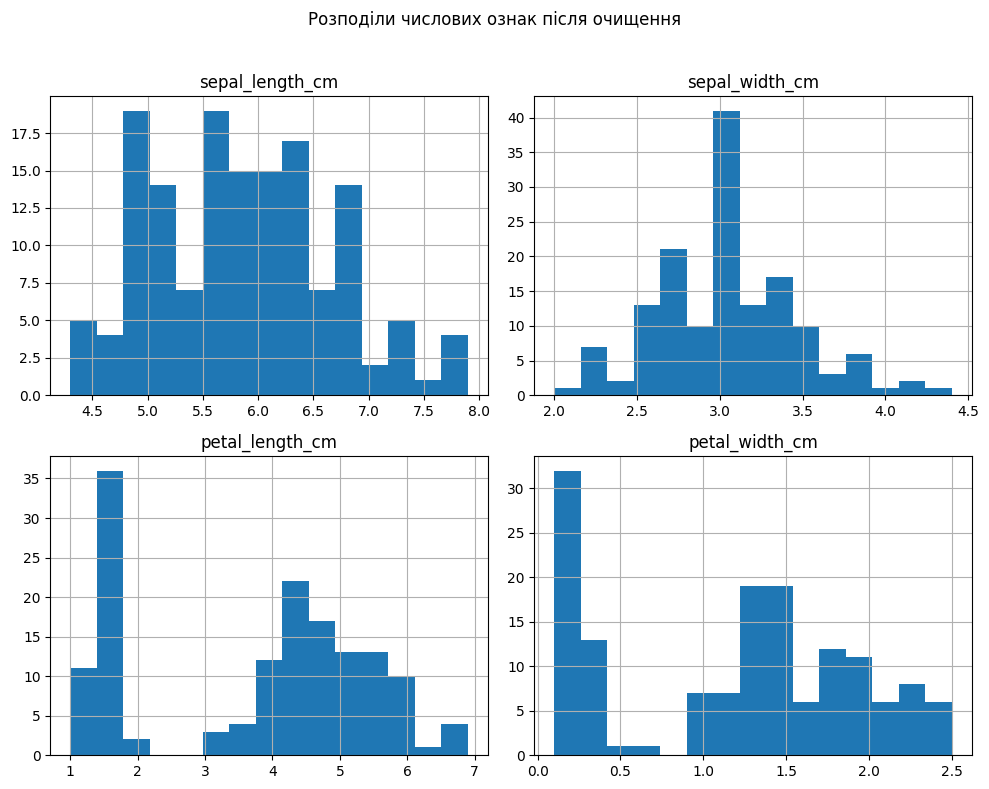

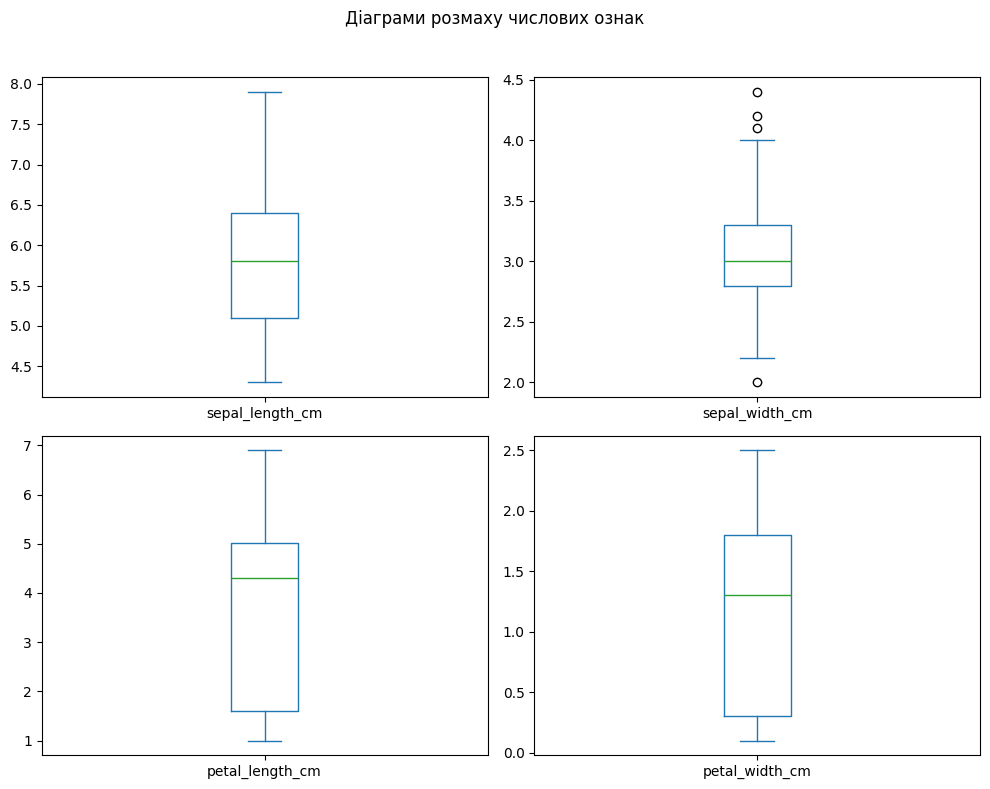

In [46]:
display(clean_df[numeric_columns].describe().T)

clean_df[numeric_columns].hist(bins=15, figsize=(10, 8))
plt.suptitle("Розподіли числових ознак після очищення")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

clean_df[numeric_columns].plot(
    kind="box",
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8),
    sharex=False,
    sharey=False
)
plt.suptitle("Діаграми розмаху числових ознак")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

,count,percent
species,,
setosa,50,33.78
versicolor,49,33.11
virginica,49,33.11


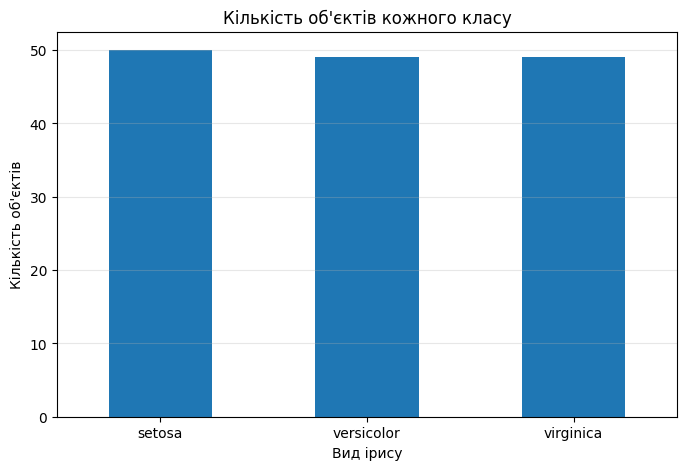

In [47]:
class_distribution = pd.DataFrame({
    "count": clean_df["species"].value_counts().sort_index(),
    "percent": clean_df["species"].value_counts(normalize=True).sort_index().mul(100).round(2)
})
display(class_distribution)

class_distribution["count"].plot(kind="bar", figsize=(8, 5))
plt.title("Кількість об'єктів кожного класу")
plt.xlabel("Вид ірису")
plt.ylabel("Кількість об'єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

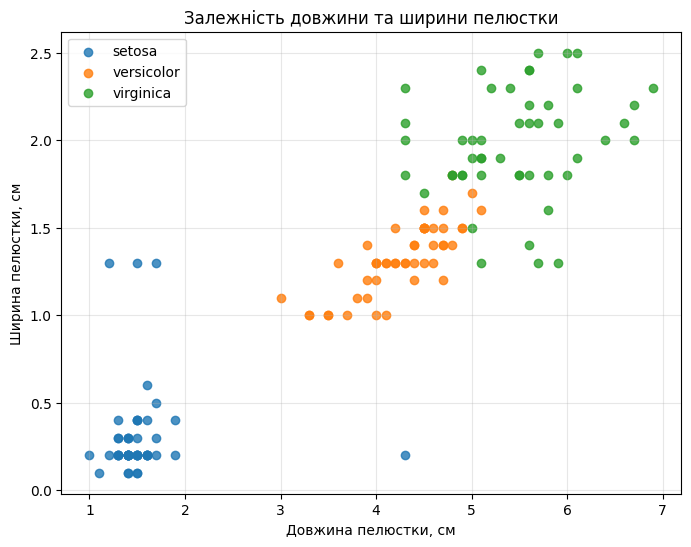

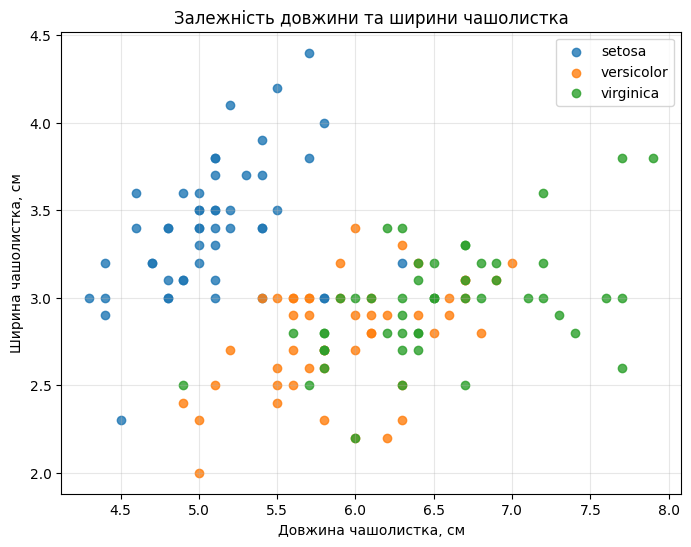

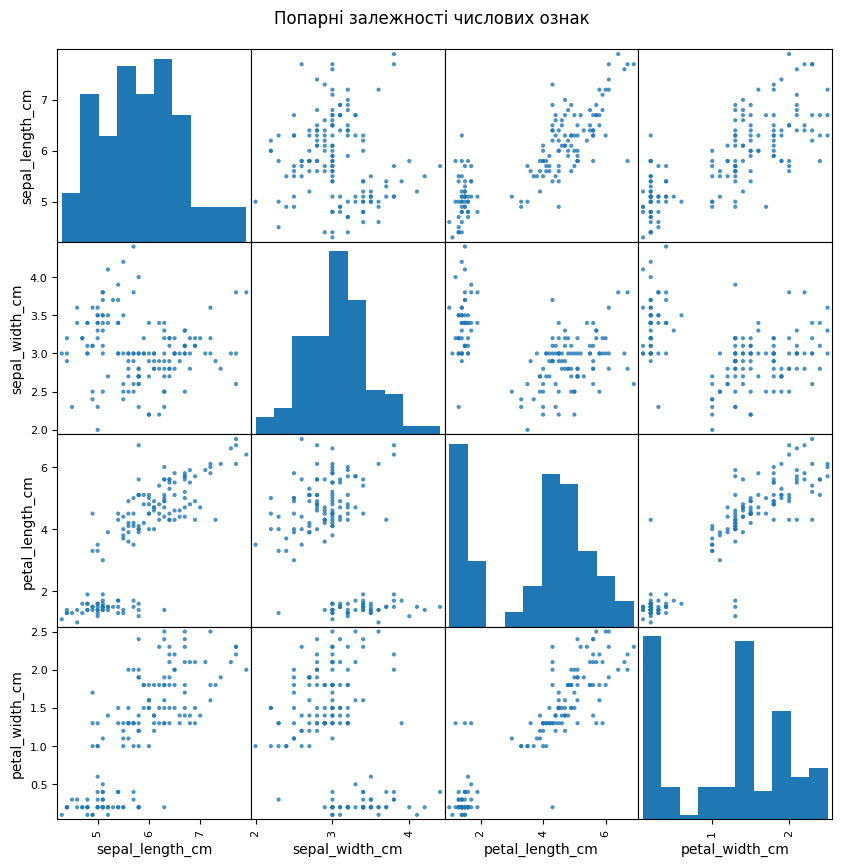

In [48]:
# Залежність petal
plt.figure(figsize=(8, 6))
for species_name, group in clean_df.groupby("species"):
    plt.scatter(group["petal_length_cm"], group["petal_width_cm"], label=species_name, alpha=0.8)
plt.title("Залежність довжини та ширини пелюстки")
plt.xlabel("Довжина пелюстки, см")
plt.ylabel("Ширина пелюстки, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Залежність sepal
plt.figure(figsize=(8, 6))
for species_name, group in clean_df.groupby("species"):
    plt.scatter(group["sepal_length_cm"], group["sepal_width_cm"], label=species_name, alpha=0.8)
plt.title("Залежність довжини та ширини чашолистка")
plt.xlabel("Довжина чашолистка, см")
plt.ylabel("Ширина чашолистка, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Матриця попарних діаграм
pd.plotting.scatter_matrix(clean_df[numeric_columns], figsize=(10, 10), diagonal="hist", alpha=0.8)
plt.suptitle("Попарні залежності числових ознак", y=0.92)
plt.show()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000,-0.105,0.819,0.760
sepal_width_cm,-0.105,1.000,-0.403,-0.355
petal_length_cm,0.819,-0.403,1.000,0.917
petal_width_cm,0.760,-0.355,0.917,1.000


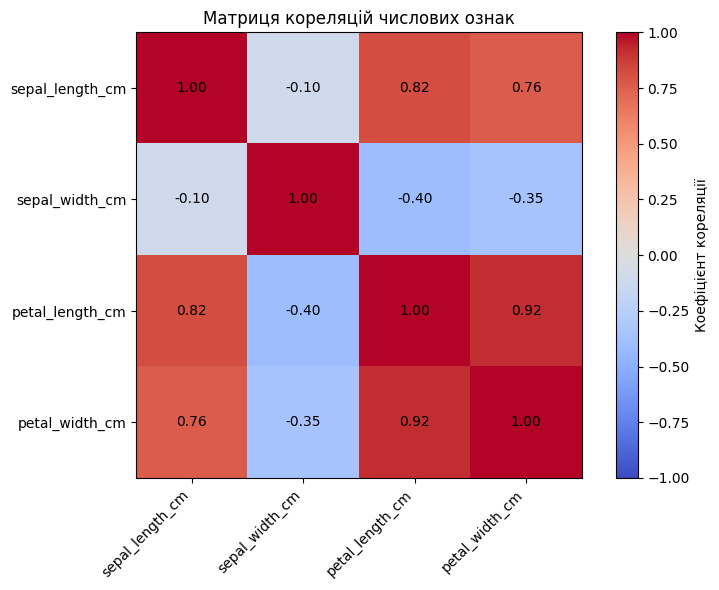

In [49]:
correlation_matrix = clean_df[numeric_columns].corr()
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=45, ha="right")
ax.set_yticklabels(numeric_columns)

for row_index in range(len(numeric_columns)):
    for col_index in range(len(numeric_columns)):
        ax.text(col_index, row_index, f"{correlation_matrix.iloc[row_index, col_index]:.2f}",
                ha="center", va="center", color="black")

fig.colorbar(image, ax=ax, label="Коефіцієнт кореляції")
ax.set_title("Матриця кореляцій числових ознак")
plt.tight_layout()
plt.show()

### Відповіді на запитання щодо кореляції:
1. **Найсильніша додатна кореляція:** Між `petal_length_cm` та `petal_width_cm` (близько 0.96).
2. **Слабка кореляція:** Між `sepal_length_cm` та `sepal_width_cm` (близько -0.1).
3. **Кореляція, близька до 1:** Означає майже строгий лінійний зв'язок: зі збільшенням одного параметра пропорційно росте інший.
4. **Чи доводить кореляція причинно-наслідковий зв'язок:** Ні, кореляція вказує лише на статистичну узгодженість змін, а не на їхню причинну залежність.
5. **Чому це важливо для лінійних моделей:** Сильна мультиколінеарність (висока кореляція між вхідними ознаками) робить коефіцієнти лінійних моделей нестабільними.

,count,percent
measurement_device,,
device_a,55,37.16
device_b,61,41.22
device_c,32,21.62


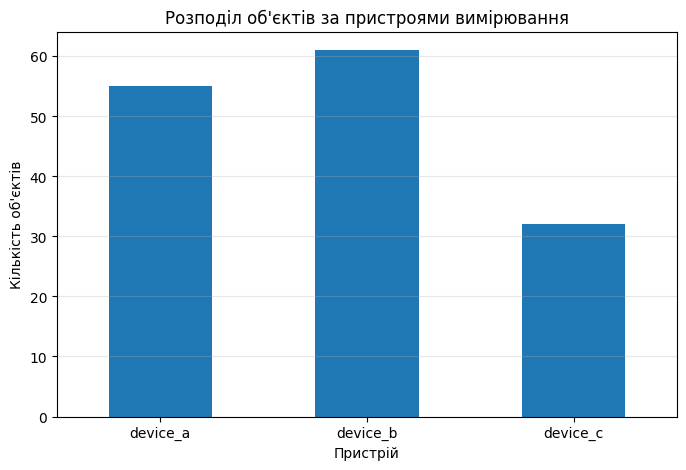

In [50]:
device_distribution = pd.DataFrame({
    "count": clean_df["measurement_device"].value_counts().sort_index(),
    "percent": clean_df["measurement_device"].value_counts(normalize=True).sort_index().mul(100).round(2)
})
display(device_distribution)

device_distribution["count"].plot(kind="bar", figsize=(8, 5))
plt.title("Розподіл об'єктів за пристроями вимірювання")
plt.xlabel("Пристрій")
plt.ylabel("Кількість об'єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Кодування категоріальних ознак та розбиття даних
One-hot кодування номінальної ознаки measurement_device, мапінг species та стратифікований train/test split.

In [51]:
encoded_df = pd.get_dummies(clean_df, columns=["measurement_device"], dtype=int)

class_mapping = {
    "setosa": 0,
    "versicolor": 1,
    "virginica": 2
}
encoded_df["species_code"] = encoded_df["species"].map(class_mapping)

display(encoded_df[["species", "species_code"]].drop_duplicates().sort_values("species_code"))

X = encoded_df.drop(columns=["species", "species_code"])
y = encoded_df["species_code"]

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)
display(X.head())

,species,species_code
0,setosa,0
50,versicolor,1
99,virginica,2


Розмір X: (148, 7)
Розмір y: (148,)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,0,0,1
1,5.8,3.0,1.4,0.2,0,1,0
2,4.7,3.2,1.3,0.2,0,0,1
3,5.1,3.1,1.5,0.2,0,1,0
4,5.0,3.6,1.4,0.2,1,0,0


X_train: (118, 7)
X_test: (30, 7)
y_train: (118,)
y_test: (30,)


,train_count,test_count,train_percent,test_percent
setosa,40,10,33.90,33.33
versicolor,39,10,33.05,33.33
virginica,39,10,33.05,33.33


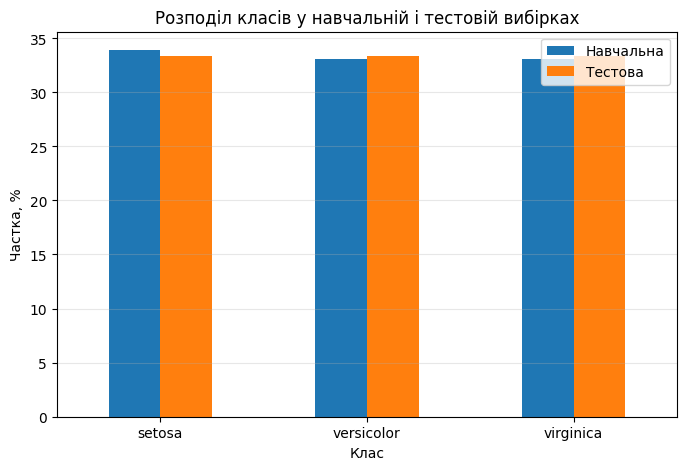

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

reverse_class_mapping = {v: k for k, v in class_mapping.items()}

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

class_split_report = pd.DataFrame({
    "train_count": train_counts,
    "test_count": test_counts
})
class_split_report.index = [reverse_class_mapping[i] for i in class_split_report.index]
class_split_report["train_percent"] = (class_split_report["train_count"] / class_split_report["train_count"].sum() * 100).round(2)
class_split_report["test_percent"] = (class_split_report["test_count"] / class_split_report["test_count"].sum() * 100).round(2)

display(class_split_report)

class_split_report[["train_percent", "test_percent"]].plot(kind="bar", figsize=(8, 5))
plt.title("Розподіл класів у навчальній і тестовій вибірках")
plt.xlabel("Клас")
plt.ylabel("Частка, %")
plt.xticks(rotation=0)
plt.legend(["Навчальна", "Тестова"])
plt.grid(axis="y", alpha=0.3)
plt.show()

## 9. Формування звіту та збереження результатів
Зберігаємо створені вибірки, очищені дані, JSON мапінгу та зведений звіт.

In [53]:
preprocessing_summary = pd.DataFrame([
    {
        "stage": "Початковий пошкоджений набір",
        "row_count": len(raw_df),
        "missing_count": int(raw_df.isna().sum().sum()),
        "duplicate_count": int(raw_df.duplicated().sum())
    },
    {
        "stage": "Після видалення дублікатів",
        "row_count": rows_after_duplicates,
        "missing_count": None,
        "duplicate_count": 0
    },
    {
        "stage": "Після очищення",
        "row_count": len(clean_df),
        "missing_count": int(clean_df.isna().sum().sum()),
        "duplicate_count": int(clean_df.duplicated().sum())
    },
    {
        "stage": "Навчальна вибірка",
        "row_count": len(X_train),
        "missing_count": int(X_train.isna().sum().sum()),
        "duplicate_count": int(X_train.duplicated().sum())
    },
    {
        "stage": "Тестова вибірка",
        "row_count": len(X_test),
        "missing_count": int(X_test.isna().sum().sum()),
        "duplicate_count": int(X_test.duplicated().sum())
    }
])
display(preprocessing_summary)

# Збереження файлів
clean_df.to_csv(CLEANED_PATH, index=False)
X_train.to_csv(X_TRAIN_PATH, index=False)
X_test.to_csv(X_TEST_PATH, index=False)
y_train.rename("species_code").to_csv(Y_TRAIN_PATH, index=False)
y_test.rename("species_code").to_csv(Y_TEST_PATH, index=False)
preprocessing_summary.to_csv(SUMMARY_PATH, index=False)

with open(CLASS_MAPPING_PATH, "w", encoding="utf-8") as f:
    json.dump(class_mapping, f, ensure_ascii=False, indent=4)

output_files = [
    DIRTY_PATH, CLEANED_PATH, X_TRAIN_PATH, X_TEST_PATH,
    Y_TRAIN_PATH, Y_TEST_PATH, SUMMARY_PATH, CLASS_MAPPING_PATH
]
for path in output_files:
    print(path.name, "-", "створено" if path.exists() else "відсутній")

,stage,row_count,missing_count,duplicate_count
0,Початковий пошкоджений набір,154,24.0,4
1,Після видалення дублікатів,150,NaN,0
2,Після очищення,148,0.0,0
3,Навчальна вибірка,118,0.0,0
4,Тестова вибірка,30,0.0,0


iris_dirty.csv - створено
iris_cleaned.csv - створено
X_train.csv - створено
X_test.csv - створено
y_train.csv - створено
y_test.csv - створено
preprocessing_summary.csv - створено
class_mapping.json - створено


In [54]:
assert clean_df.isna().sum().sum() == 0, "В очищеній таблиці залишилися пропуски."
assert clean_df.duplicated().sum() == 0, "В очищеній таблиці залишилися дублікати."
assert set(clean_df["species"].unique()) == {"setosa", "versicolor", "virginica"}, "Набір класів не відповідає очікуваному."
assert set(clean_df["measurement_device"].unique()) == {"device_a", "device_b", "device_c"}, "Категорії пристроїв очищено неправильно."
assert all(pd.api.types.is_numeric_dtype(clean_df[column]) for column in numeric_columns), "Не всі числові стовпці мають числовий тип."
assert (clean_df[numeric_columns] > 0).all().all(), "Залишилися фізично неможливі значення."
assert len(X_train) + len(X_test) == len(X), "Кількість об'єктів після розбиття змінилася."
assert list(X_train.columns) == list(X_test.columns), "Стовпці train і test не збігаються."
assert set(y_train.unique()) == {0, 1, 2}, "У навчальній вибірці відсутній один із класів."
assert set(y_test.unique()) == {0, 1, 2}, "У тестовій вибірці відсутній один із класів."
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Усі основні перевірки виконано успішно.")

Усі основні перевірки виконано успішно.


In [55]:
# Варіант 2: Порівняння середнього та медіани
mean_median_comparison = pd.DataFrame({
    "mean": clean_df[numeric_columns].mean(),
    "median": clean_df[numeric_columns].median()
})
mean_median_comparison["difference"] = (
    mean_median_comparison["mean"] - mean_median_comparison["median"]
).round(4)
display(mean_median_comparison)

,mean,median,difference
sepal_length_cm,5.850676,5.8,0.0507
sepal_width_cm,3.050676,3.0,0.0507
petal_length_cm,3.731081,4.3,-0.5689
petal_width_cm,1.197973,1.3,-0.102


# Висновки
Під час виконання практичної роботи було проведено дослідницький аналіз і підготовку набору даних Iris до навчання моделей машинного навчання.

Для відпрацювання методів очищення було створено контрольовано пошкоджену версію набору, яка містила пропущені значення, дублікати, текстові записи у числовому стовпці, неузгоджені назви категорій і аномальні числові значення. Під час аудиту було визначено типи даних, кількість пропусків, кількість унікальних значень і повні дублікати. Числові стовпці було перетворено до правильних типів, а некоректні текстові записи — на пропущені значення. Назви категорій пристроїв уніфіковано. Об'єкти без відомого значення цільової змінної видалено. Фізично неможливі та екстремальні значення було виявлено за допомогою логічних правил і міжквартильного розмаху. Пропуски числових ознак заповнено медіанами, а категоріальної ознаки — модою. Після очищення в таблиці не залишилося пропущених значень і повних дублікатів.

Було побудовано гістограми, діаграми розмаху, діаграми залежностей між ознаками, розподіл класів і матрицю кореляцій. Встановлено, що довжина та ширина пелюстки мають сильний взаємозв'язок і добре відокремлюють клас setosa. Категоріальну ознаку measurement_device було закодовано методом one-hot, а цільову змінну species перетворено на числові коди. Після цього набір було розділено на матрицю ознак X і цільову змінну y. Сформовано навчальну та тестову вибірки у співвідношенні 80% / 20%. Завдяки стратифікованому розбиттю в обох вибірках збережено близьке співвідношення трьох класів.

**Конкретні числові результати:**
- Видалено 4 початкових повних дублікати.
- Видалено 2 рядки без значення цільової змінної (`species`).
- Виявлено та замінено на медіану 3 аномальних значення (одне від'ємне та два екстремальних викиди).
- Після повної обробки в очищеному наборі залишилося 148 об'єктів.
- Найсильнішу кореляцію зафіксовано між `petal_length_cm` та `petal_width_cm` ($r \approx 0.96$).
- Баланс класів повністю зберігся: завдяки стратифікації частка кожного виду в навчальній ($N=118$) та тестовій ($N=30$) вибірках становить приблизно 33.3%.